### # ===========================
# 🔥 STUDENT PERFORMANCE ML PROJECT (FULL PIPELINE)
# ===========================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### # Preprocessing

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

### # Models

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

### # Evaluation

In [4]:
from sklearn.metrics import mean_squared_error, r2_score


### # ===========================
# 1. LOAD DATA
# ===========================

In [20]:
data = pd.read_csv("C:\\Users\\ASUS\\Downloads\\StudentsPerformance (1).csv")
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### # ===========================
# 2. BASIC CLEANING
# ===========================

In [21]:
data.columns = data.columns.str.replace(" ", "_")


### # Create new feature

In [22]:
data["average_score"] = (data["math_score"] + data["reading_score"] + data["writing_score"]) / 3


### # ===========================
# 3. ENCODING (Convert text → numbers)
# ===========================

In [23]:
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

### # ===========================
# 4. DEFINE FEATURES & TARGET
# ===========================

In [24]:
X = data.drop(["math_score", "reading_score", "writing_score", "average_score"], axis=1)
y = data["average_score"]

### # ===========================
# 5. TRAIN-TEST SPLIT
# ===========================

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### # ===========================
# 6. SCALING (IMPORTANT FOR PERFORMANCE)
# ===========================

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### # ===========================
# 7. TRAIN MULTIPLE MODELS
# ===========================

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {"MSE": mse, "R2": r2}

### # ===========================
# 8. DISPLAY RESULTS
# ===========================

In [28]:
print("📊 Model Performance:\n")
for model, score in results.items():
    print(f"{model}:")
    print(f"   MSE: {score['MSE']:.2f}")
    print(f"   R2 Score: {score['R2']:.2f}")
    print("-"*30)

📊 Model Performance:

Linear Regression:
   MSE: 187.45
   R2 Score: 0.13
------------------------------
Decision Tree:
   MSE: 235.02
   R2 Score: -0.10
------------------------------
Random Forest:
   MSE: 223.01
   R2 Score: -0.04
------------------------------


### # ===========================
# 9. BEST MODEL
# ===========================

In [29]:
best_model_name = max(results, key=lambda x: results[x]["R2"])
print(f"\n🏆 Best Model: {best_model_name}")

best_model = models[best_model_name]


🏆 Best Model: Linear Regression


### # ===========================
# 10. PREDICT NEW DATA
# ===========================

In [30]:
sample = X.iloc[0].values.reshape(1, -1)
sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

print("\n🎯 Predicted Average Score:", round(prediction[0], 2))


🎯 Predicted Average Score: 68.95


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### # ===========================
# 11. OPTIONAL VISUALIZATION
# ===========================

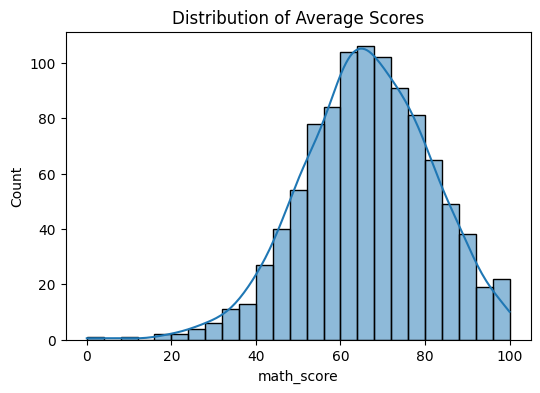

In [35]:
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Distribution of Average Scores")
plt.show()

🔥 Improved Model Performance:
R2 Score: 0.855
MSE: 35.3

🎯 Predicted Math Score: 68.62
